# HW 5, Problem 3: 3DVAR

## How the cycle works on $[0, 10]$

Observations arrive every $\delta t = 0.1$, at $t_k = k\,\delta t$ for $k = 1, \dots, 100$. Starting from an initial guess $\tilde x_0$ (the climatological mean $\mu$, since before any data that is the best estimate consistent with $B$):

1. **Forecast:** run the model from the current estimate $\tilde x_{k-1}$ over $[t_{k-1}, t_k]$. The state that arrives at $t_k$ is the background $\mu_k = M(\tilde x_{k-1})$.
2. **Analysis:** combine $\mu_k$ with $y_k$ by minimizing the 3DVAR cost, giving $\tilde x_k$. In gain form (no $B^{-1}$ needed):
$$\tilde x_k = \mu_k + K\,(y_k - H\mu_k), \qquad K = BH^T(HBH^T + R)^{-1}.$$
3. Repeat from $\tilde x_k$.

The assimilated trajectory is therefore piecewise: smooth model forecasts between observations, with a jump at each $t_k$ where the analysis corrects the state. Because $B$, $H$, and $R$ are fixed, $K$ is computed once and every cycle costs one forecast plus one matrix-vector product.

The truth is a separate run of the same model from a point on the attractor (perfect-model setting), and $y_k = Hx_k + \eta_k$ with $\eta_k \sim N(0, \sigma^2 I)$, $\sigma = p \cdot \operatorname{mean}_i|\mu_i|$, $p \in \{1\%, 10\%\}$. Each case shares one noise realization across noise levels (and with 4DVAR in Problem 5).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from da_models import hw5
from da_models.assimilation import (
    make_3dvar, free_run, run_cycle, time_integrated_rmse, final_time_rmse,
)
from da_models.da_plots import plot_case_timeseries, plot_case_hovmoller, plot_error_summary

DATA_DIR = "../data"   # adjust if running in Colab
models = {name: hw5.load_model(name, DATA_DIR) for name in hw5.MODELS}

## Check: the gain form really minimizes the 3DVAR cost

Before running anything, compare one analysis step against a direct numerical minimization of $J$ (Lorenz-63, $x$ only, 10% noise, an arbitrary background).

In [2]:
model = models["lorenz63"]
case = hw5.build_case(model, "x only", 0.10)
B, H, R = model["B"], case["H"], case["R"]
background = case["truth"][4, -1] + np.array([1.0, -2.0, 3.0])
y = case["Y"][4]

Bi, Ri = np.linalg.inv(B), np.linalg.inv(R)
J = lambda x: 0.5 * (y - H @ x) @ Ri @ (y - H @ x) + 0.5 * (x - background) @ Bi @ (x - background)

x_direct = minimize(J, background, tol=1e-12).x
x_gain = make_3dvar(H, R, B, case["Y"])(5, background)
print("gain form:      ", x_gain)
print("direct minimum: ", x_direct)
print("max difference: ", np.abs(x_gain - x_direct).max())

gain form:       [ 7.72513823 -2.41768556 37.3446154 ]
direct minimum:  [ 7.72513823 -2.41768558 37.3446154 ]
max difference:  1.4741421416886169e-08


## Run every case

12 runs: 3 models × 2 observation operators × 2 noise levels, plus one free run (no assimilation) per model as a reference. Timing is the wall-clock time of the full cycle on $[0, 10]$ (forecasts and analyses), best of 3 repeats.

In [3]:
REPEATS = 3

def timed_run(case, analyze):
    best = None
    for _ in range(REPEATS):
        run = run_cycle(case["propagate"], case["x_guess0"], case["n_cycles"], analyze)
        if best is None or run["wall_time"] < best["wall_time"]:
            best = run
    return best

results = {name: [] for name in models}     # name -> list of (case, run)
free_runs = {}
for name, model in models.items():
    for op in hw5.MODELS[name]["operators"]:
        for p in hw5.NOISE_LEVELS:
            case = hw5.build_case(model, op, p)
            run = timed_run(case, make_3dvar(case["H"], case["R"], model["B"], case["Y"]))
            results[name].append((case, run))
    first_case = results[name][0][0]
    free_runs[name] = timed_run(first_case, free_run())

## Summary table

RMSE as defined in the assignment (full state, not normalized by dimension). Because Sturis variables differ in scale by a factor of about 50, the last column also reports a **scale-free** version: the time-integrated RMSE computed after dividing each variable by its climatological standard deviation $\sqrt{B_{ii}}$, then dividing by $\sqrt{n}$. A value of 1 means the error is as large as the natural variability.

In [4]:
def scaled_rmse(case, run, model):
    sd = np.sqrt(np.diag(model["B"]))
    n = len(sd)
    return time_integrated_rmse(case["truth"] / sd, run["segments"] / sd, case["dt"]) / np.sqrt(n)

rows = []
for name, model in models.items():
    for case, run in results[name]:
        rows.append((name, case["operator"], f"{case['noise_level']:.0%}",
                     time_integrated_rmse(case["truth"], run["segments"], case["dt"]),
                     final_time_rmse(case["truth"], run), scaled_rmse(case, run, model),
                     run["wall_time"]))
    case0 = results[name][0][0]
    free = free_runs[name]
    rows.append((name, "free run (no DA)", "-",
                 time_integrated_rmse(case0["truth"], free["segments"], case0["dt"]),
                 final_time_rmse(case0["truth"], free), scaled_rmse(case0, free, model),
                 free["wall_time"]))

header = f"{'model':<10} {'observing':<18} {'noise':>5} {'RMSE [0,T]':>11} {'RMSE at T':>10} {'scaled':>7} {'time (s)':>9}"
print(header); print("-" * len(header))
for r in rows:
    print(f"{r[0]:<10} {r[1]:<18} {r[2]:>5} {r[3]:>11.4g} {r[4]:>10.4g} {r[5]:>7.3f} {r[6]:>9.3f}")

model      observing          noise  RMSE [0,T]  RMSE at T  scaled  time (s)
----------------------------------------------------------------------------
lorenz63   identity              1%      0.5501     0.1303   0.037     0.120
lorenz63   identity             10%       1.402       1.24   0.094     0.126
lorenz63   x only                1%      0.6874     0.1815   0.046     0.123
lorenz63   x only               10%       2.047      1.806   0.137     0.127
lorenz63   free run (no DA)       -        20.5      14.83   1.389     0.116
lorenz96   identity              1%       2.417     0.1387   0.105     0.374
lorenz96   identity             10%       2.834      1.379   0.123     0.391
lorenz96   every other site      1%       13.04      1.936   0.567     0.415
lorenz96   every other site     10%       12.22      1.916   0.531     0.395
lorenz96   free run (no DA)       -       33.31      27.21   1.447     0.379
sturis     identity              1%       77.93      20.68   0.346     0.033

## Lorenz-63

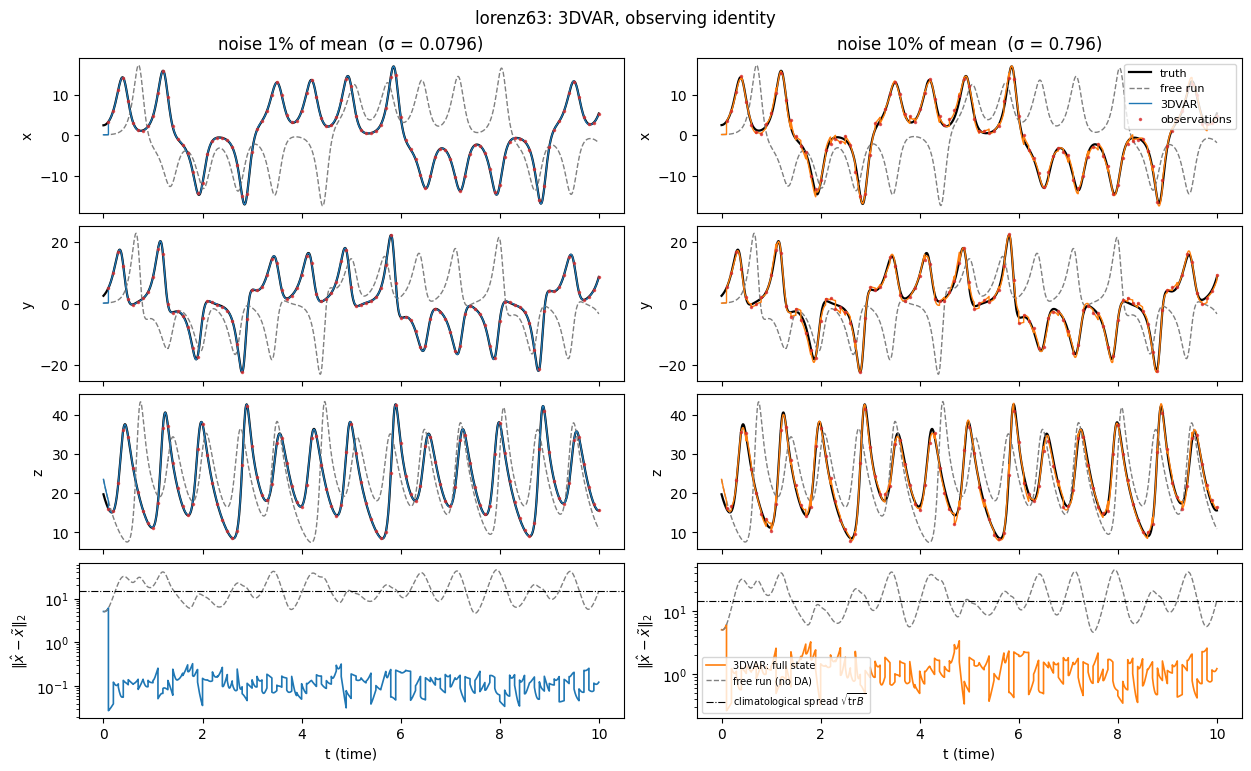

In [5]:
name = "lorenz63"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "identity"]
plot_case_timeseries(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

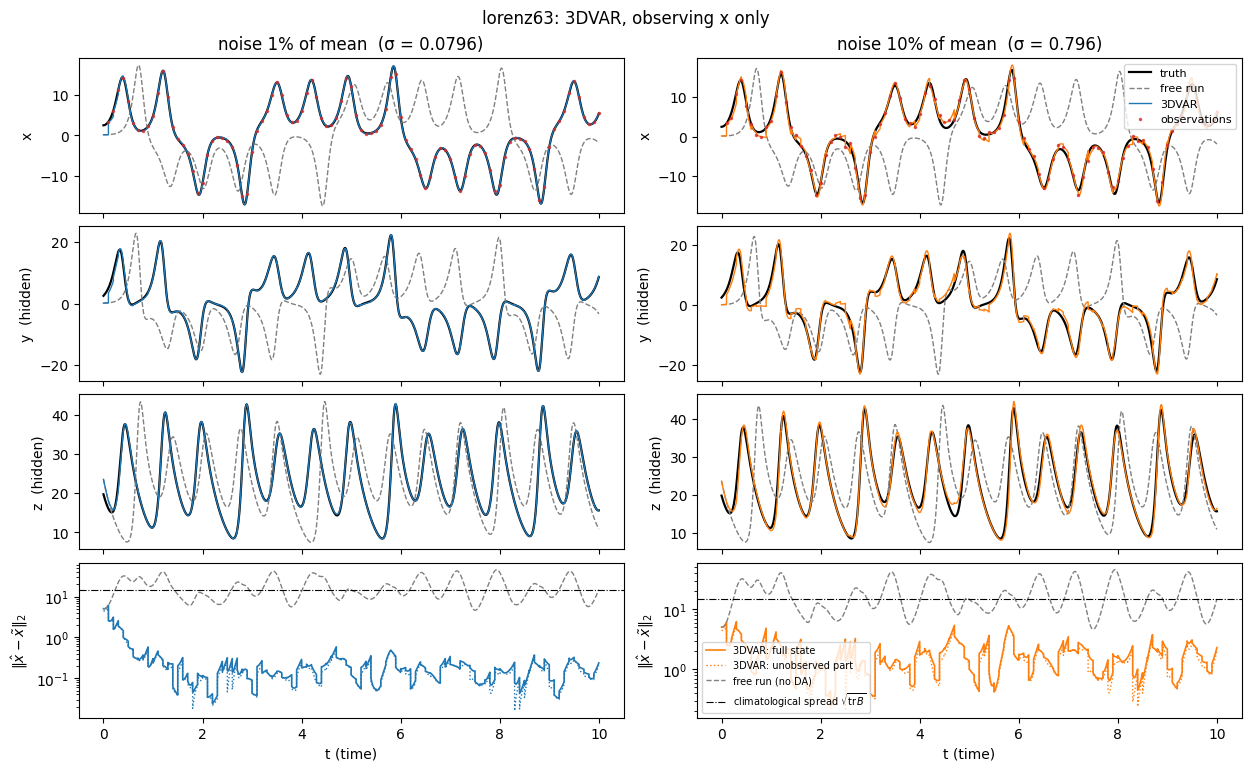

In [6]:
name = "lorenz63"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "x only"]
plot_case_timeseries(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

**Discussion:** 

## Lorenz-96 (one layer, $K = 40$)

Space-time (Hovmöller) plots: horizontal axis is time, vertical axis is the site index, color is the state value.

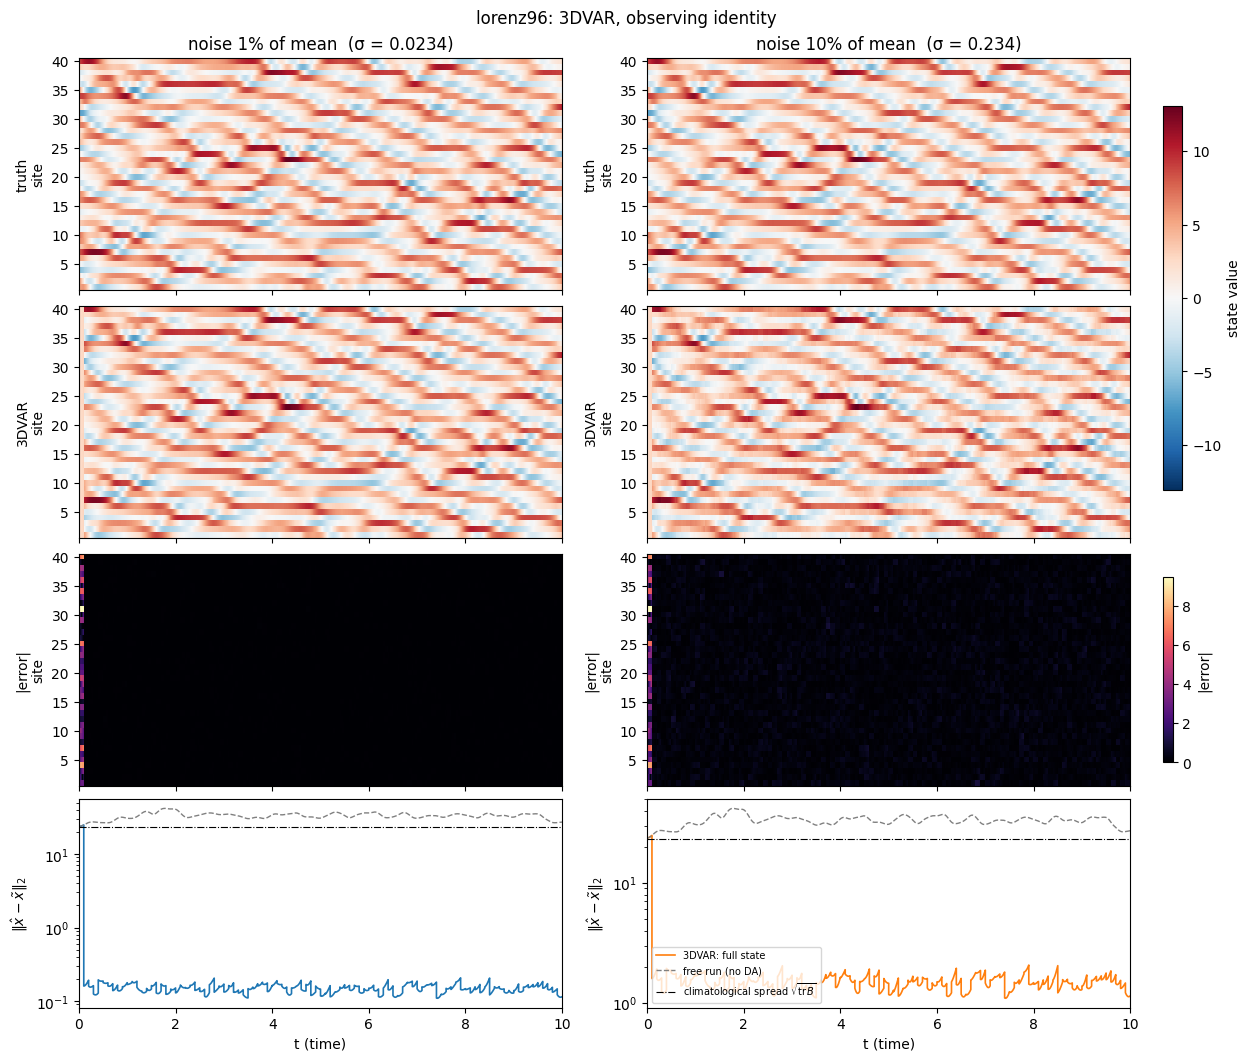

In [7]:
name = "lorenz96"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "identity"]
plot_case_hovmoller(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

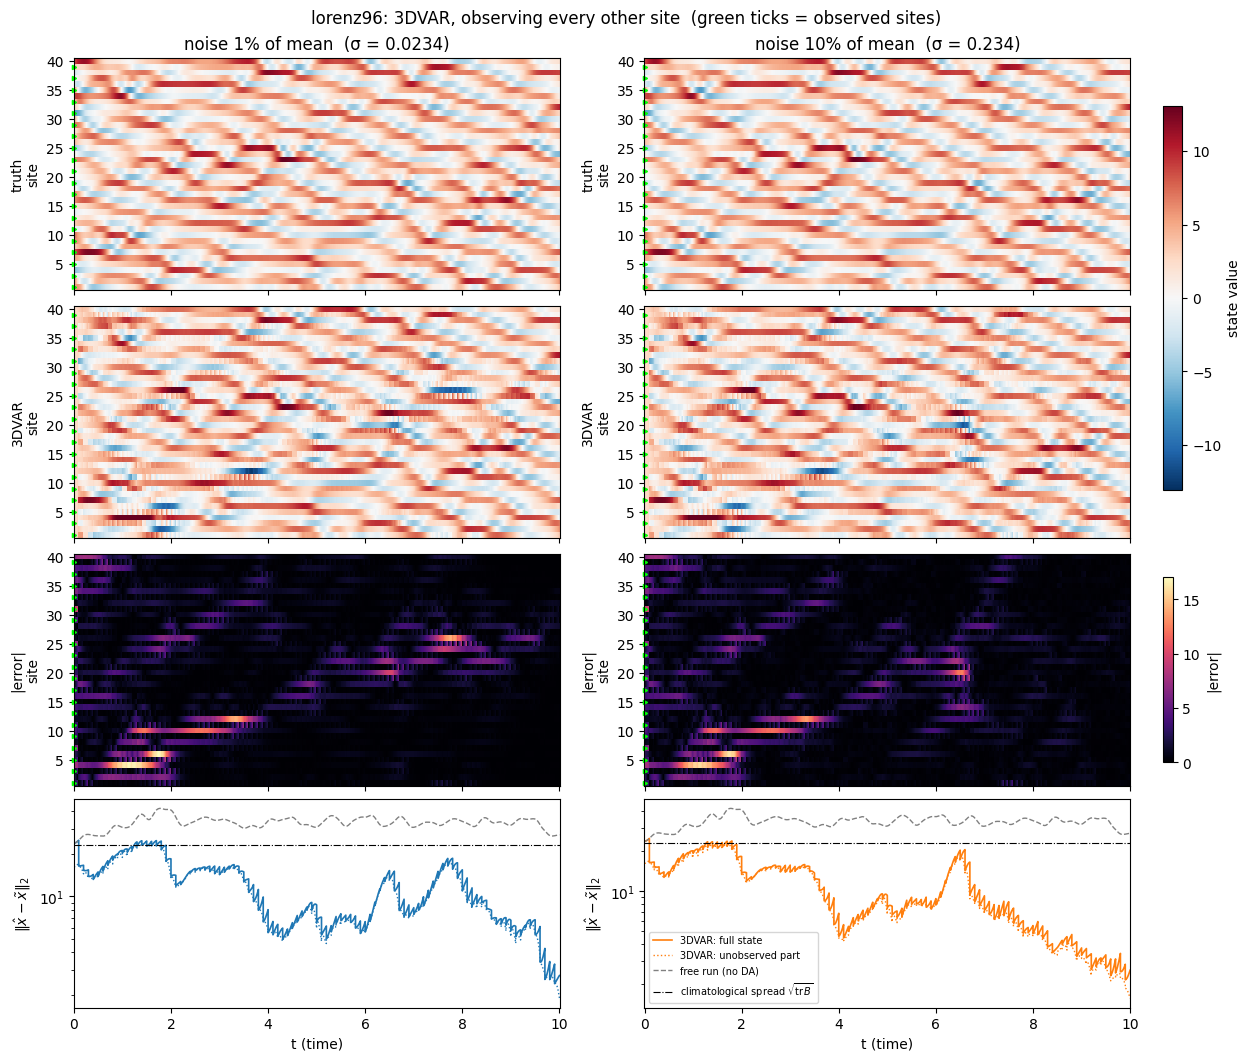

In [8]:
name = "lorenz96"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "every other site"]
plot_case_hovmoller(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

**Discussion:** 

## Sturis ($I_G = 216$ mg/min)

Time is in minutes, so $[0, 10]$ covers about 9% of one ~110-minute ultradian cycle.

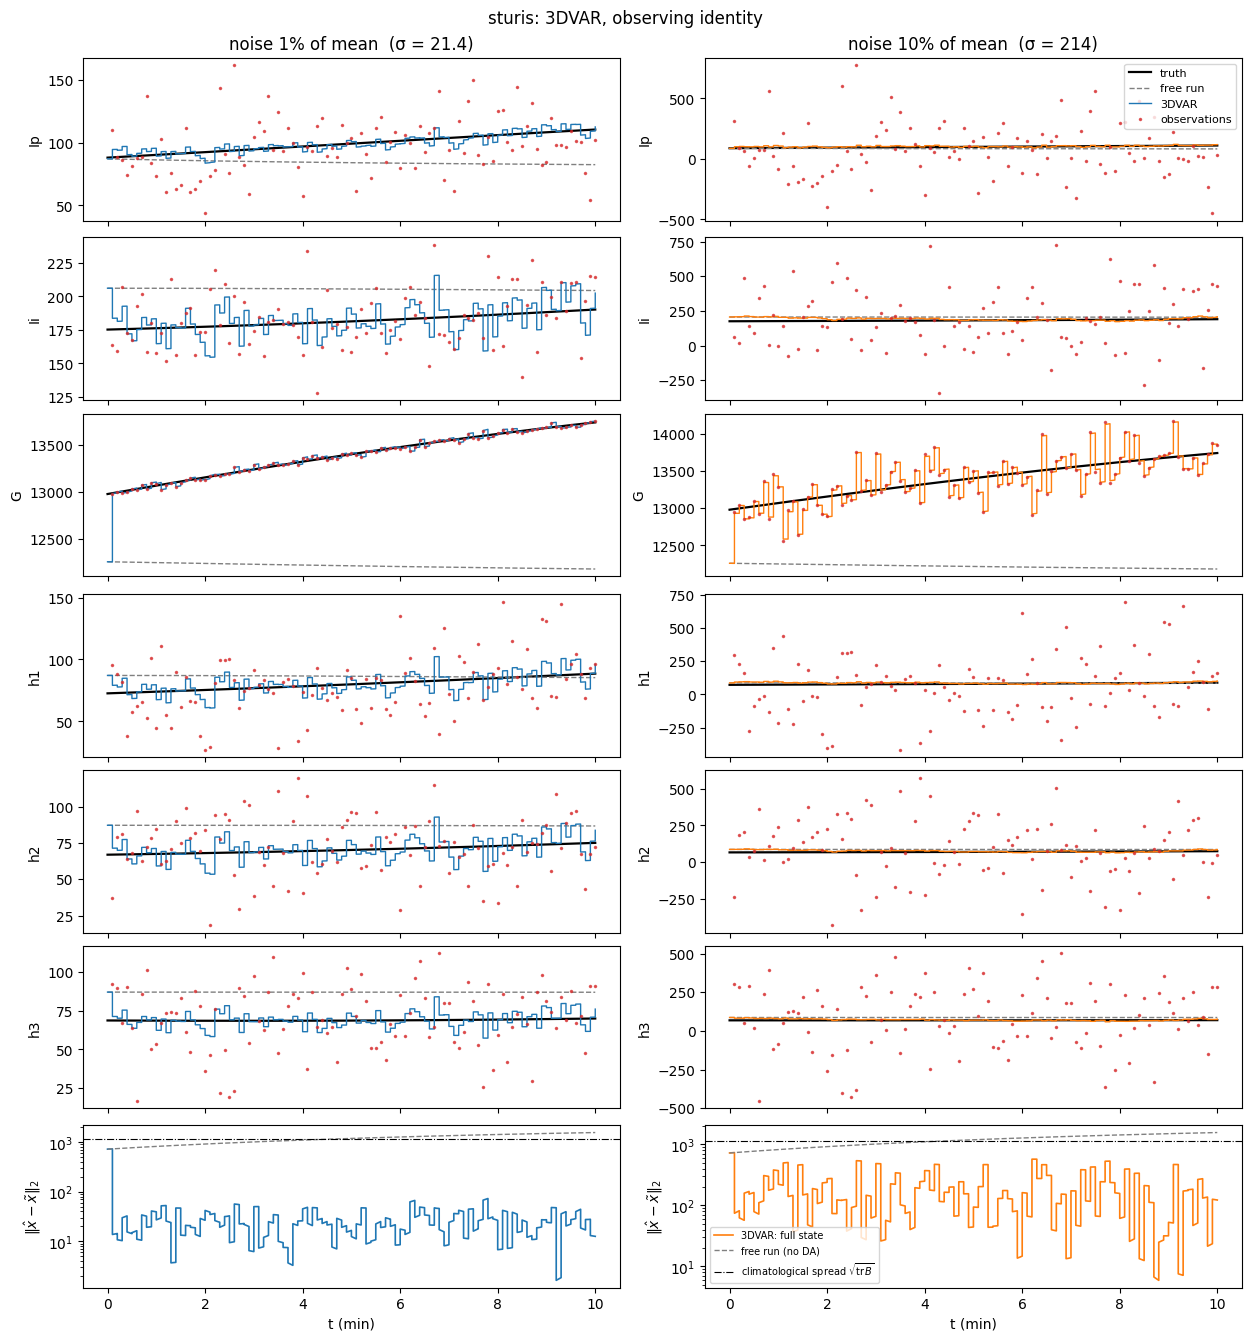

In [9]:
name = "sturis"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "identity"]
plot_case_timeseries(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

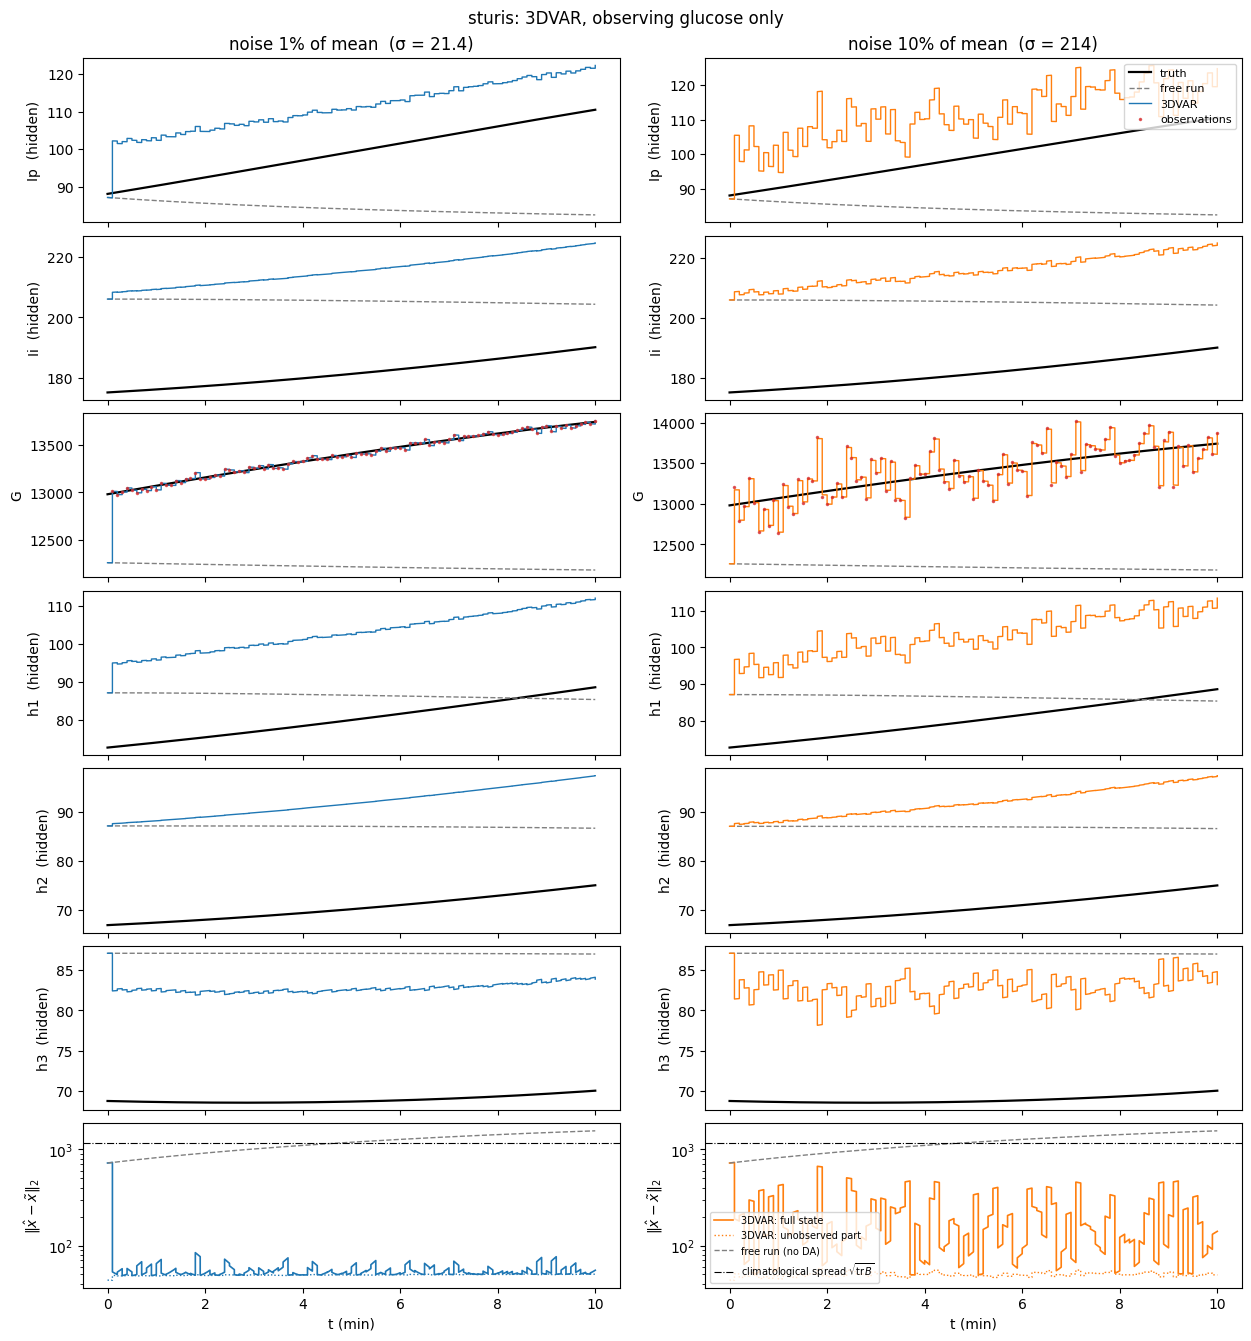

In [10]:
name = "sturis"
cases_runs = [(c, r) for c, r in results[name] if c["operator"] == "glucose only"]
plot_case_timeseries(models[name], [c for c, _ in cases_runs], [r for _, r in cases_runs], free_runs[name])
plt.show()

**Discussion:** 

## All cases at a glance

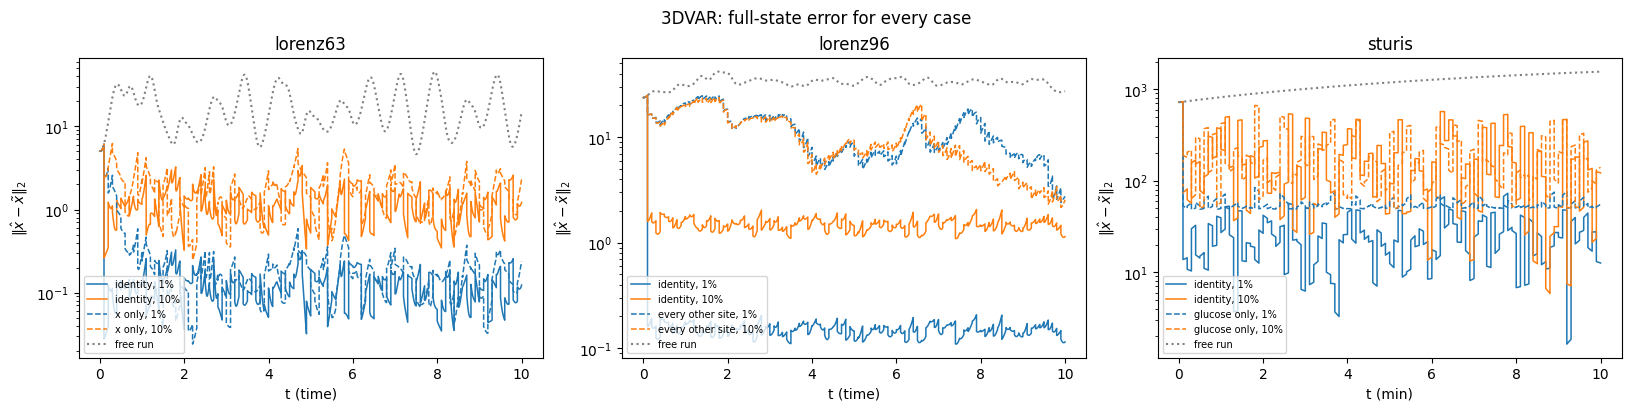

In [11]:
plot_error_summary(models, results, free_runs)
plt.show()